# 05 — Model Evaluation & Final Prediction

Evaluate price and direction models, compare actual versus predicted values, then retrain on all historical data for the final next-day forecast.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

files = list(Path("../data").glob("*.csv")) or list(Path("data").glob("*.csv"))
if not files:
    raise FileNotFoundError("Place the Reliance OHLCV CSV in the project's data/ folder.")
df = pd.read_csv(files[0])
df.columns = df.columns.str.strip()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
for c in ["Open","High","Low","Close","Volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["Date","Open","High","Low","Close"]).drop_duplicates().sort_values("Date").reset_index(drop=True)
df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2000-01-03,RELIANCE,EQ,233.05,237.50,251.70,237.50,251.70,251.70,249.37,4456424,1.111319e+14,NaN,NaN,NaN
1,2000-01-04,RELIANCE,EQ,251.70,258.40,271.85,251.30,271.85,271.85,263.52,9487878,2.500222e+14,NaN,NaN,NaN
2,2000-01-05,RELIANCE,EQ,271.85,256.65,287.90,256.65,286.75,282.50,274.79,26833684,7.373697e+14,NaN,NaN,NaN
3,2000-01-06,RELIANCE,EQ,282.50,289.00,300.70,289.00,293.50,294.35,295.45,15682286,4.633254e+14,NaN,NaN,NaN
4,2000-01-07,RELIANCE,EQ,294.35,295.00,317.90,293.00,314.50,314.55,308.91,19870977,6.138388e+14,NaN,NaN,NaN


In [2]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score
import joblib, json

p=df["Close"]
f=pd.DataFrame(index=df.index)
f["Return_1D"]=p.pct_change(); f["Return_5D"]=p.pct_change(5); f["Return_10D"]=p.pct_change(10)
f["SMA5_Ratio"]=p/p.rolling(5).mean()-1; f["SMA20_Ratio"]=p/p.rolling(20).mean()-1
f["Volatility_5D"]=f["Return_1D"].rolling(5).std(); f["Volatility_20D"]=f["Return_1D"].rolling(20).std()
f["Daily_Range"]=(df["High"]-df["Low"])/df["Close"]; f["Volume_Change"]=df["Volume"].pct_change()
d=p.diff(); g=d.clip(lower=0).rolling(14).mean(); l=(-d.clip(upper=0)).rolling(14).mean()
f["RSI"]=100-100/(1+g/l)
data=pd.concat([f,p.shift(-1).rename("Next_Close"),(p.shift(-1)>p).astype(int).rename("Direction"),p.rename("Close")],axis=1).dropna()
features=f.columns.tolist()
cut=int(len(data)*.8); train,test=data.iloc[:cut],data.iloc[cut:]

price_model=Pipeline([("imputer",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",Ridge(alpha=1.0))])
direction_model=Pipeline([("imputer",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",LogisticRegression(max_iter=2000))])
price_model.fit(train[features],train["Next_Close"]); direction_model.fit(train[features],train["Direction"])
pp=price_model.predict(test[features]); dp=direction_model.predict(test[features])

In [3]:
actual=test["Next_Close"].to_numpy()
print("MAE:",mean_absolute_error(actual,pp))
print("RMSE:",np.sqrt(mean_squared_error(actual,pp)))
print("R²:",r2_score(actual,pp))
print("Direction Accuracy:",accuracy_score(test["Direction"],dp))
print("Precision:",precision_score(test["Direction"],dp,zero_division=0))
print("Recall:",recall_score(test["Direction"],dp,zero_division=0))
print("F1:",f1_score(test["Direction"],dp,zero_division=0))

MAE: 493.86089306088246
RMSE: 617.5743978603616
R²: -1.5373752498804945
Direction Accuracy: 0.5127719962157048
Precision: 0.5188141391106044
Recall: 0.8302919708029197
F1: 0.6385964912280702


KeyError: 'Date'

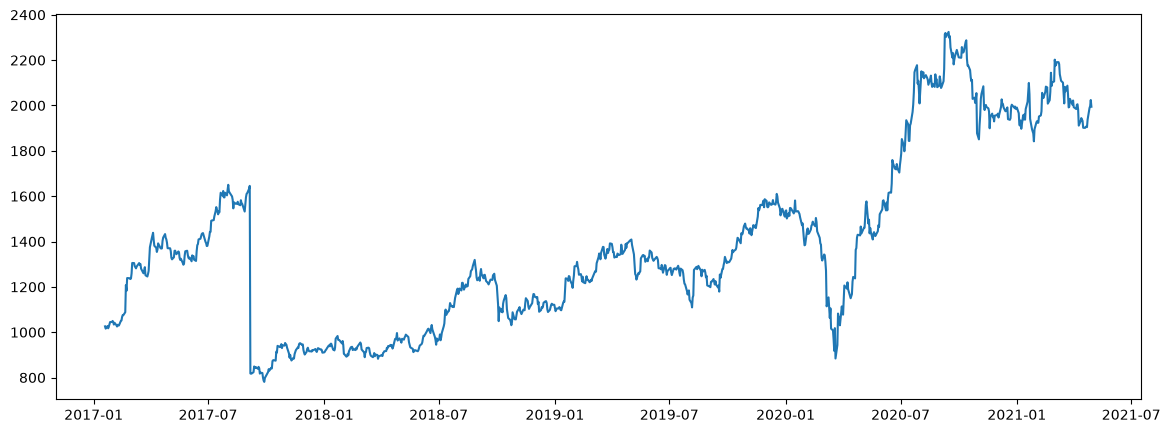

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df.loc[test.index, "Date"], actual, label="Actual")
plt.plot(df.loc[test.index, "Date"], pp, label="Predicted")
plt.title("Actual vs Predicted Next-Day Close"); plt.legend(); plt.grid(alpha=.25); plt.show()

In [ ]:
# Final training and next-day prediction
final_price=Pipeline([("imputer",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",Ridge(alpha=1.0))])
final_direction=Pipeline([("imputer",SimpleImputer(strategy="median")),("scale",StandardScaler()),("model",LogisticRegression(max_iter=2000))])
final_price.fit(data[features],data["Next_Close"]); final_direction.fit(data[features],data["Direction"])
latest=f.dropna().iloc[[-1]]
next_close=float(final_price.predict(latest[features])[0])
direction=int(final_direction.predict(latest[features])[0])
print("Latest Close:",float(df.loc[latest.index[0],"Close"]))
print("Predicted Next Close:",next_close)
print("Predicted Direction:","UP" if direction else "DOWN")

In [ ]:
artifacts=Path("../artifacts")
if not artifacts.exists(): artifacts=Path("artifacts")
artifacts.mkdir(exist_ok=True)
joblib.dump(final_price,artifacts/"price_model.pkl")
joblib.dump(final_direction,artifacts/"direction_model.pkl")
(artifacts/"feature_config.json").write_text(json.dumps({"features":features,"price_column":"Close","target_price":"Next_Close","target_direction":"Direction"},indent=2))
print("Artifacts saved:",artifacts.resolve())